Memproses perkalian 2 citra sesuai pseudocode...
Selesai!


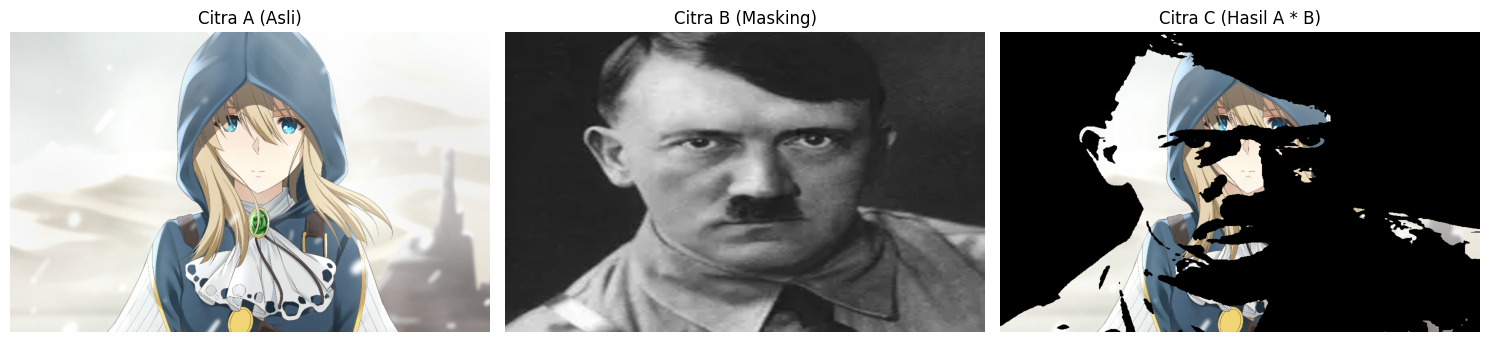

In [6]:
#Operasi Perkalian 2 Citra
from PIL import Image
import matplotlib.pyplot as plt

def image_to_array(img):
    width, height = img.size
    pixels = list(img.getdata())
    A = []
    for row in range(height):
        A.append(pixels[row * width : (row + 1) * width])
    return A, height, width

def array_to_image(B, M, N):
    flat = []
    for row in B:
        flat.extend(row)
    img = Image.new("RGB", (N, M))
    img.putdata(flat)
    return img

def multiplication_2_citra(citra_A, citra_B, M, N):
    citra_C = [[(0, 0, 0) for j in range(N)] for i in range(M)]

    for i in range(M):
        for j in range(N):
            r_A, g_A, b_A = citra_A[i][j]
            r_B, g_B, b_B = citra_B[i][j]

            r_C = r_A * r_B
            g_C = g_A * g_B
            b_C = b_A * b_B

            if r_C < 0:
                r_C = 0
            elif r_C > 255:
                r_C = 255

            if g_C < 0:
                g_C = 0
            elif g_C > 255:
                g_C = 255

            if b_C < 0:
                b_C = 0
            elif b_C > 255:
                b_C = 255

            citra_C[i][j] = (int(r_C), int(g_C), int(b_C))

    return citra_C

file_citra_A = "gambar_bunga.jpg"
file_citra_B = "gambar_mask.jpg"

try:
    img_A = Image.open(file_citra_A).convert("RGB")
    array_A, M, N = image_to_array(img_A)

    img_B = Image.open(file_citra_B).convert("RGB").resize((N, M))
    array_B, M_B, N_B = image_to_array(img_B)

    for i in range(M):
        for j in range(N):
            r, g, b = array_B[i][j]
            array_B[i][j] = (1 if r > 127 else 0, 1 if g > 127 else 0, 1 if b > 127 else 0)

    array_C = multiplication_2_citra(array_A, array_B, M, N)

    img_C = array_to_image(array_C, M, N)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_A)
    axes[0].set_title("Citra A (Asli)")
    axes[0].axis("off")

    axes[1].imshow(img_B)
    axes[1].set_title("Citra B (Masking)")
    axes[1].axis("off")

    axes[2].imshow(img_C)
    axes[2].set_title("Citra C (Hasil A * B)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error: {e}. Pastikan nama file gambar sudah benar dan berada di folder yang sama.")

Memproses perkalian citra dengan skalar...
Selesai!


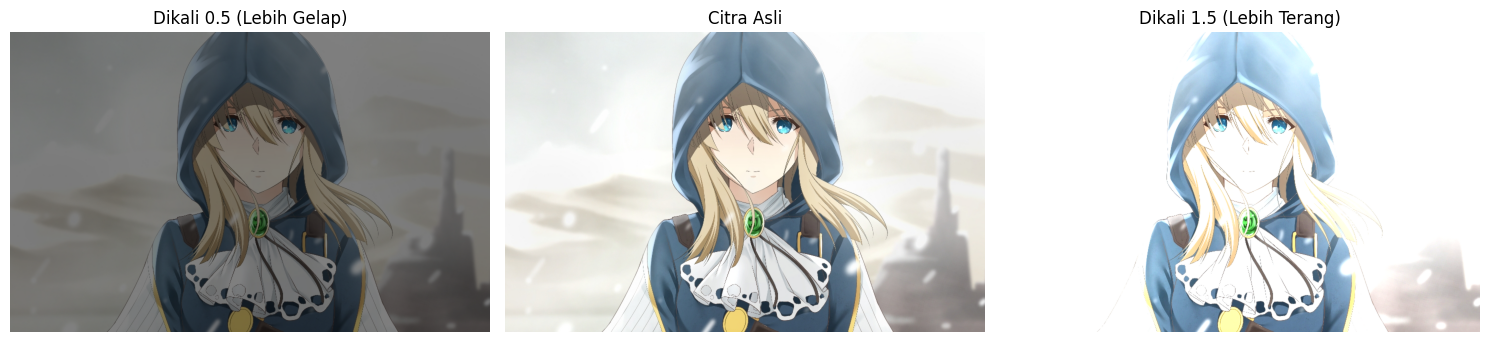

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

def image_to_array(img):
    width, height = img.size
    pixels = list(img.getdata())
    A = []
    for row in range(height):
        A.append(pixels[row * width : (row + 1) * width])
    return A, height, width

def array_to_image(B, M, N):
    flat = []
    for row in B:
        flat.extend(row)
    img = Image.new("RGB", (N, M))
    img.putdata(flat)
    return img

def multiplication_scalar(citra_A, scalar, M, N):
    citra_C = [[(0, 0, 0) for j in range(N)] for i in range(M)]

    for i in range(M):
        for j in range(N):
            r_A, g_A, b_A = citra_A[i][j]

            r_C = int(r_A * scalar)
            g_C = int(g_A * scalar)
            b_C = int(b_A * scalar)

            if r_C < 0:
                r_C = 0
            elif r_C > 255:
                r_C = 255

            if g_C < 0:
                g_C = 0
            elif g_C > 255:
                g_C = 255

            if b_C < 0:
                b_C = 0
            elif b_C > 255:
                b_C = 255

            citra_C[i][j] = (r_C, g_C, b_C)

    return citra_C

file_citra = "/content/AnimeX_896261.jpeg"

try:
    img_A = Image.open(file_citra).convert("RGB")
    array_A, M, N = image_to_array(img_A)

    print("Memproses perkalian citra dengan skalar...")

    array_gelap = multiplication_scalar(array_A, 0.5, M, N)
    img_gelap = array_to_image(array_gelap, M, N)

    array_terang = multiplication_scalar(array_A, 1.5, M, N)
    img_terang = array_to_image(array_terang, M, N)

    print("Selesai!")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(img_gelap)
    axes[0].set_title("Dikali 0.5 (Lebih Gelap)")
    axes[0].axis("off")

    axes[1].imshow(img_A)
    axes[1].set_title("Citra Asli")
    axes[1].axis("off")

    axes[2].imshow(img_terang)
    axes[2].set_title("Dikali 1.5 (Lebih Terang)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

except FileNotFoundError as e:
    print(f"Error: {e}. Pastikan nama file gambar sudah benar dan berada di folder yang sama.")